Neural Network Analysis
==============================================================
Research Questions addressed:

The Neural Network below doesn't  directly answer any of the research questions. It is a predictor, not an explainer. It takes the features, mashes them through 16 hidden units (neurons) in one hidden layer, and outputs "at risk / not at risk" with 77% accuracy. It never tells you which feature drove that decision, and by design it can't — the weights are distributed across the hidden units with no interpretable mapping back to specific feature values. The accuracy scores and confusion matrices below all refer to how well the entire selected feature set collectively predicts hypertension risk using the neural network. 


Install libraries (as needed)

In [1]:
# uncomment line below to install tensorflow if needed
#%pip install tensorflow 

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f'{x:,.4f}')


Load dataset

In [3]:
ht_risk_df = pd.read_csv('../data/nhanes_hypertension_risk.csv')
ht_risk_df

,participant_id,age,race_ethnicity,education,poverty_income_ratio,marital_status,diagnosed_high_bp,diagnosed_twice,on_chol_medication,bmi,waist_cm,weight_kg,height_cm,smoked_100_cigarettes,smoke_frequency,avg_drinks_per_day,time_sitting,total_cholesterol_mgdl,HDL_cholesterol_mgdl,fasting_glucose_mgdl,LDL_cholesterol_mgdl_friedewald,LDL_cholesterol_mgdl_martin,LDL_cholesterol_mgdl_nih,systolic_avg,systolic_clinical,diastolic_avg,diastolic_clinical,pulse_avg,pulse_clinical,hypertension_risk,male,ever_smoker,current_smoker,drinks_alcohol,drink_frequency_past_year,high_cholesterol,moderate_minutes_per_week,vigorous_minutes_per_week,physically_active
0,130378,43.0000,Non-Hispanic Asian,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,27.0000,98.3000,86.9000,179.5000,1.0000,3.0000,1.3333,360.0000,264.0000,45.0000,113.0000,188.0000,190.0000,191.0000,132.6667,131.5000,96.0000,95.0000,81.0000,80.5000,1,1,1,0,1,208.0000,0,135.0000,135.0000,1
1,130379,66.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,33.5000,114.7000,101.8000,174.2000,1.0000,3.0000,3.0000,480.0000,214.0000,60.0000,125.3333,137.0000,135.0000,139.0000,117.0000,115.0000,78.6667,76.0000,72.0000,72.0000,1,1,1,0,1,300.0000,0,180.0000,135.0000,1
2,130380,44.0000,Other Hispanic,HS/GED or equivalent,1.4100,Married/Living with Partner,0,0.0000,Yes,29.7000,93.5000,69.4000,152.9000,2.0000,3.0000,1.0000,240.0000,187.0000,49.0000,156.0000,63.0000,90.0000,78.0000,109.0000,108.0000,78.3333,78.0000,81.3333,80.0000,1,0,0,0,1,1.0000,1,20.0000,21.9045,0
3,130386,34.0000,Mexican American,Some college or AA degree,1.3300,Married/Living with Partner,0,0.0000,No,30.2000,106.1000,90.6000,173.3000,1.0000,3.0000,2.0000,180.0000,183.0000,46.0000,100.0000,109.0000,111.0000,112.0000,115.0000,117.5000,73.6667,74.5000,62.3333,64.0000,0,1,1,0,1,104.0000,0,30.0000,6.9045,0
4,130394,51.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,0,0.0000,No,24.4000,92.1000,76.7000,177.3000,2.0000,3.0000,1.0000,420.0000,183.0000,48.0000,88.0000,124.0000,120.0000,124.0000,110.6667,116.5000,68.0000,67.5000,79.6667,80.5000,0,1,0,0,1,24.0000,0,0.0000,120.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,142301,80.0000,Non-Hispanic White,College graduate or above,1.2000,Widowed/Divorced/Separated,1,1.0000,No,30.5000,79.7000,82.2000,164.3000,1.0000,3.0000,2.0000,360.0000,138.0000,48.0000,110.0000,61.0000,67.0000,65.0000,140.4444,112.1667,75.3333,72.8333,69.7778,79.0000,1,0,1,0,1,1.0000,1,76.4020,21.9045,0
3558,142303,69.0000,Non-Hispanic White,HS/GED or equivalent,0.9800,Widowed/Divorced/Separated,0,0.0000,Yes,27.9000,111.0000,70.8000,159.2000,1.0000,3.0000,0.0000,360.0000,110.0000,34.0000,160.0000,45.0000,53.0000,50.0000,127.0000,126.0000,69.3333,68.5000,75.3333,75.0000,1,0,1,0,0,0.0000,0,840.0000,95.0000,1
3559,142305,76.0000,Mexican American,<HS,2.2500,Widowed/Divorced/Separated,1,1.0000,Yes,26.4000,89.0000,60.4000,151.4000,2.0000,3.0000,1.3333,480.0000,180.0000,51.0000,132.0000,92.0000,101.0000,97.0000,143.6667,146.0000,79.3333,78.5000,70.6667,70.5000,1,0,0,0,1,17.3333,1,80.0000,21.9045,0
3560,142308,50.0000,Other Hispanic,Some college or AA degree,1.9500,Married/Living with Partner,0,0.0000,No,26.4000,98.4000,79.3000,173.3000,2.0000,3.0000,2.0000,600.0000,166.0000,42.6667,112.6667,61.3333,122.6667,88.6667,108.0000,109.0000,69.3333,71.5000,62.6667,65.0000,0,1,0,0,1,8.0000,0,45.0000,24.6030,0


Configuration Settings

In [4]:
output_dir  = "../visualizations/models/"
seed = 7
keras.utils.set_random_seed(seed)     # used in model creation and training to ensure reproducibility

palette = "Set2"

# define feature columns
feature_cols = [
    'age', 'race_ethnicity', 'male', 'education', 'marital_status',
    'poverty_income_ratio', 'bmi', 'total_cholesterol_mgdl', 
    'physically_active', 'time_sitting', 'current_smoker', 'ever_smoker',
    'drinks_alcohol', 'avg_drinks_per_day', 'drink_frequency_past_year'
]

print(feature_cols)
print(len(feature_cols), 'input features')

# define output feature (target)
target_col = 'hypertension_risk'
print('distribution of target value:\n', ht_risk_df[target_col].value_counts())

['age', 'race_ethnicity', 'male', 'education', 'marital_status', 'poverty_income_ratio', 'bmi', 'total_cholesterol_mgdl', 'physically_active', 'time_sitting', 'current_smoker', 'ever_smoker', 'drinks_alcohol', 'avg_drinks_per_day', 'drink_frequency_past_year']
15 input features
distribution of target value:
 hypertension_risk
1    2145
0    1417
Name: count, dtype: int64


---

Additional Transformations/Preprocessing Needed for Neural Networks

In [5]:
# one-hot encode the categorical columns
ht_risk_model = ht_risk_df.copy()

X = ht_risk_model[feature_cols]
y = ht_risk_model[target_col]

categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = X.select_dtypes(include=[np.number]).columns.tolist()

# split data into training and testing sets (80/20 split) - stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

# preprocessing: one-hot encode categoricals, scale numerics
scaler = StandardScaler()
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

# fit on training data
X_train_num = scaler.fit_transform(X_train[numeric])
X_train_cat = encoder.fit_transform(X_train[categorical])
X_train_num_df = pd.DataFrame(X_train_num, columns=numeric, index=X_train.index)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(categorical), index=X_train.index)
X_train = pd.concat([X_train_num_df, X_train_cat_df], axis=1)

# fit on test data
X_test_num = scaler.transform(X_test[numeric])
X_test_cat = encoder.transform(X_test[categorical])
X_test_num_df = pd.DataFrame(X_test_num, columns=numeric, index=X_test.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoder.get_feature_names_out(categorical), index=X_test.index)
X_test = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

# examine shape:
print(X_train.shape)  # rows = participants, columns = input risk-factor features
print(X_test.shape)  
print(y_train.shape) # one hypertension_risk label per participant
print(y_test.shape)

# print snapshots:
print(X_train.head()) 
print(X_test.head())  
print(y_train.head()) 
print(y_test.head())

(2849, 22)
(713, 22)
(2849,)
(713,)
         age    male  poverty_income_ratio     bmi  total_cholesterol_mgdl  physically_active  time_sitting  current_smoker  ever_smoker  \
3300  1.5169 -0.9071                0.1975 -1.3932                  0.5883            -0.8842       -0.0337         -0.3249       1.2544   
1780  1.5169  1.1025                1.2570 -0.0660                  0.5231             1.1310       -0.6174         -0.3249       1.2544   
148  -1.2445 -0.9071               -0.8049  0.1778                 -0.5112            -0.8842       -0.6174         -0.3249      -0.7972   
1832 -1.2998 -0.9071               -0.6590  4.3084                 -1.2930            -0.8842       -0.3255         -0.3249      -0.7972   
2592 -0.5266  1.1025               -0.3291 -0.1879                  2.3963             1.1310       -0.0337         -0.3249      -0.7972   

      drinks_alcohol  avg_drinks_per_day  drink_frequency_past_year  race_ethnicity_Non-Hispanic Asian  race_ethnicity_Non-

1. Build the Neural Network

Activations chosen: ReLU (hidden layer), Sigmoid (output layer)


In [6]:
keras.utils.set_random_seed(seed)

model = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train.shape[1],)), # input layer with shape equal to number of features
        keras.layers.Dense(16, activation="relu", name="hidden_layer"), # one hidden layer with 16 neurons and ReLU activation
        keras.layers.Dense(1, activation="sigmoid", name="output_layer"), # output layer with sigmoid activation for binary classification
    ]
)

# Derivative updates: Adam performs gradient descent using the derivatives
# of the loss w.r.t. every weight, computed by backpropagation each batch.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 16)             │           368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

2. Train with epochs

In [7]:
keras.utils.set_random_seed(seed)

early = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,              # tolerate 10 epochs with no improvement
    restore_best_weights=True # roll back to the best epoch
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,  # carve a validation set out of the training data
    callbacks=[early], # halt training when val_loss stops improving and roll back to the best weights
    verbose=2
)

Epoch 1/50
76/76 - 2s - 27ms/step - accuracy: 0.5399 - loss: 0.7098 - val_accuracy: 0.5818 - val_loss: 0.6642
Epoch 2/50
76/76 - 0s - 6ms/step - accuracy: 0.6369 - loss: 0.6368 - val_accuracy: 0.6963 - val_loss: 0.6063
Epoch 3/50
76/76 - 1s - 7ms/step - accuracy: 0.7047 - loss: 0.5854 - val_accuracy: 0.7290 - val_loss: 0.5605
Epoch 4/50
76/76 - 0s - 6ms/step - accuracy: 0.7414 - loss: 0.5476 - val_accuracy: 0.7547 - val_loss: 0.5273
Epoch 5/50
76/76 - 0s - 6ms/step - accuracy: 0.7596 - loss: 0.5243 - val_accuracy: 0.7570 - val_loss: 0.5078
Epoch 6/50
76/76 - 1s - 8ms/step - accuracy: 0.7621 - loss: 0.5115 - val_accuracy: 0.7593 - val_loss: 0.4971
Epoch 7/50
76/76 - 0s - 6ms/step - accuracy: 0.7683 - loss: 0.5041 - val_accuracy: 0.7593 - val_loss: 0.4908
Epoch 8/50
76/76 - 0s - 5ms/step - accuracy: 0.7691 - loss: 0.4993 - val_accuracy: 0.7500 - val_loss: 0.4867
Epoch 9/50
76/76 - 0s - 5ms/step - accuracy: 0.7687 - loss: 0.4958 - val_accuracy: 0.7500 - val_loss: 0.4837
Epoch 10/50
76/76 

Evaluate on the held-out test set

In [8]:
keras.utils.set_random_seed(seed)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)


print(f"\nTest accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}")
print(f"(sanity check via sklearn: {accuracy_score(y_test, y_pred):.4f})")




Test accuracy: 0.7588   Test loss: 0.5016
(sanity check via sklearn: 0.7588)


Confusion matrix image

Saved nn_confusion_matrix_optimal.png


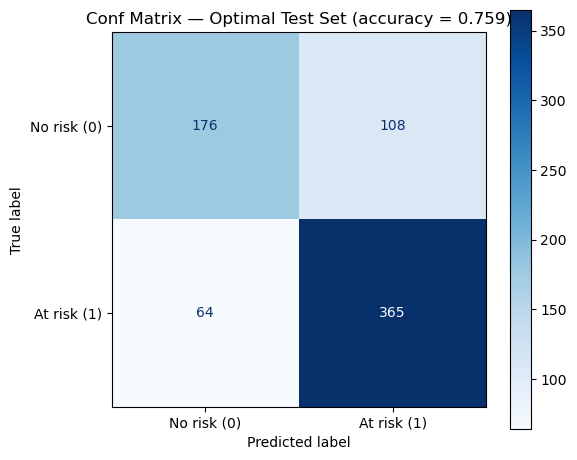

In [9]:
keras.utils.set_random_seed(seed)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No risk (0)", "At risk (1)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title(f"Conf Matrix — Optimal Test Set (accuracy = {test_acc:.3f})")
fig.tight_layout()
fig.savefig(f"{output_dir}nn_confusion_matrix_optimal.png", dpi=150)
print("Saved nn_confusion_matrix_optimal.png")
plt.show(fig)

Display last 5 epochs of training

Saved nn_last_5_epochs_optimal.png


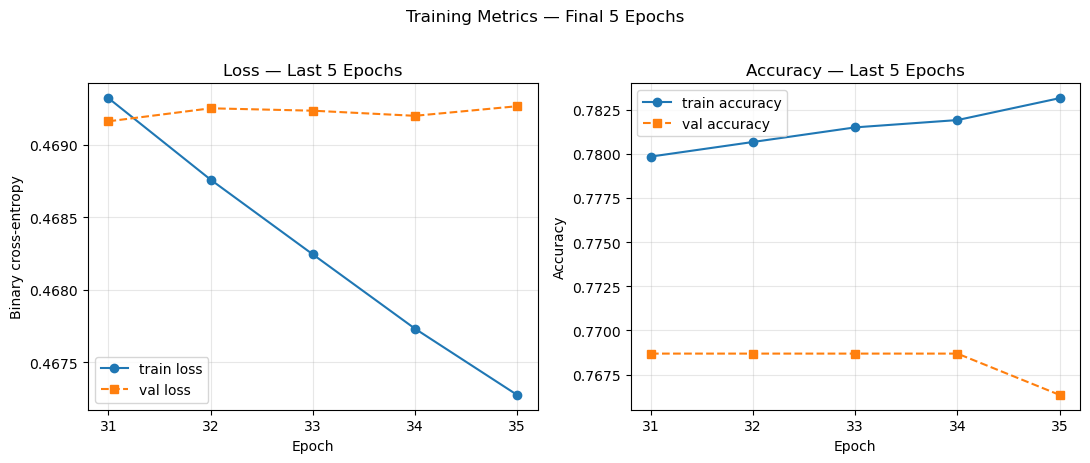


Last 5 epochs:
epoch     loss      acc  val_loss  val_acc
   31   0.4693   0.7798    0.4692   0.7687
   32   0.4688   0.7807    0.4693   0.7687
   33   0.4682   0.7815    0.4692   0.7687
   34   0.4677   0.7819    0.4692   0.7687
   35   0.4673   0.7831    0.4693   0.7664


In [10]:
epochs = 35
last5 = range(epochs - 5, epochs)               # last 5 epoch indices
epoch_labels = [e + 1 for e in last5]           # human-friendly labels for x-axis (end with 35 rather than 34)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))


ax1.plot(epoch_labels, [history.history["loss"][e] for e in last5],
         "o-", label="train loss")
ax1.plot(epoch_labels, [history.history["val_loss"][e] for e in last5],
         "s--", label="val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Binary cross-entropy")
ax1.set_title("Loss — Last 5 Epochs"); ax1.set_xticks(epoch_labels)
ax1.legend(); ax1.grid(alpha=0.3)


ax2.plot(epoch_labels, [history.history["accuracy"][e] for e in last5],
         "o-", label="train accuracy")
ax2.plot(epoch_labels, [history.history["val_accuracy"][e] for e in last5],
         "s--", label="val accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy — Last 5 Epochs"); ax2.set_xticks(epoch_labels)
ax2.legend(); ax2.grid(alpha=0.3)


fig.suptitle("Training Metrics — Final 5 Epochs", y=1.02)
fig.tight_layout()
fig.savefig(f"{output_dir}nn_last_5_epochs_optimal.png", dpi=150, bbox_inches="tight")
print("Saved nn_last_5_epochs_optimal.png")

plt.show(fig)


# Also print the last 5 epochs as a table for the console/report
print("\nLast 5 epochs:")
print(f"{'epoch':>5} {'loss':>8} {'acc':>8} {'val_loss':>9} {'val_acc':>8}")
for e in last5:
    print(f"{e + 1:>5} {history.history['loss'][e]:>8.4f} "
          f"{history.history['accuracy'][e]:>8.4f} "
          f"{history.history['val_loss'][e]:>9.4f} "
          f"{history.history['val_accuracy'][e]:>8.4f}")

